# Лабораторная работа 16 — Ассоциативные правила

**Цель:** найти ассоциативные правила в транзакционных данных (market basket analysis) с помощью алгоритма Apriori.

**Датасет (по заданию):** `groceries - groceries.csv` — классический набор для market basket analysis (Hahsler et al. 2005, 9835 чеков супермаркета). Каждая строка — одна покупка, столбцы — товары в чеке.

**Параметры Apriori (из задания):** `min_support=0.003, min_confidence=0.2, min_lift=4, min_length=2`.

Дополнительно в [`lab16_gtzan.ipynb`](lab16_gtzan.ipynb) — исследование применимости Apriori к GTZAN через бинаризацию признаков (бонус, не часть основного задания).

## Теория

**Ассоциативное правило** $X \Rightarrow Y$ означает: «если в корзине есть набор $X$, то с высокой вероятностью есть и $Y$». Например, $\{хлеб, масло\} \Rightarrow \{молоко\}$.

**Метрики:**

$$\text{support}(X) = \frac{|\{T : X \subseteq T\}|}{|D|}$$

Доля транзакций, содержащих $X$. Чем выше — тем чаще набор встречается.

$$\text{confidence}(X \Rightarrow Y) = \frac{\text{support}(X \cup Y)}{\text{support}(X)}$$

Условная вероятность $P(Y \mid X)$ — насколько надёжно $X$ предсказывает $Y$.

$$\text{lift}(X \Rightarrow Y) = \frac{\text{confidence}(X \Rightarrow Y)}{\text{support}(Y)} = \frac{P(X \cap Y)}{P(X) \cdot P(Y)}$$

Во сколько раз вероятность увидеть $Y$ при условии $X$ выше, чем без условия. **lift > 1** — положительная ассоциация; **lift = 1** — независимость; **lift < 1** — отрицательная.

**Алгоритм Apriori** строит частые наборы поэтапно (одиночки → пары → тройки), используя свойство монотонности: **если набор не частый, то и его надмножества не частые** — это срезает экспоненциальное пространство поиска.

## 1. Установка зависимостей

Раскомментируйте, если `apyori` не установлен. Для надёжности ниже есть автоматический fallback на `mlxtend` (метрики идентичны, реализация на C → быстрее).

In [1]:
# !pip install apyori

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from urllib.request import urlretrieve
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

c:\Users\ichap\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 2. Загрузка датасета

Файл `groceries - groceries.csv` берём из локальной копии `datasets/groceries/`. Если её нет — скачиваем из репозитория преподавателя `stuniy/SPO_PGU` (это тот же файл, что используется в задании, путь `/content/SPO_PGU/groceries - groceries.csv` после `git clone`).

In [3]:
DATA_PATH = Path('../../datasets/groceries/groceries.csv')
if not DATA_PATH.exists():
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    url = 'https://raw.githubusercontent.com/stuniy/SPO_PGU/master/groceries%20-%20groceries.csv'
    urlretrieve(url, DATA_PATH)
    print(f'Скачали {DATA_PATH}')

dataset = pd.read_csv(DATA_PATH)
print(f'Размер датасета: {dataset.shape[0]} строк (чеков), {dataset.shape[1]} столбцов')
dataset.head()

Размер датасета: 9835 строк (чеков), 33 столбцов


,Item(s),Item 1,Item 2,Item 3,Item 4,Item 5,Item 6,Item 7,Item 8,Item 9,...,Item 23,Item 24,Item 25,Item 26,Item 27,Item 28,Item 29,Item 30,Item 31,Item 32
0,4,citrus fruit,semi-finished bread,margarine,ready soups,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,whole milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,pip fruit,yogurt,cream cheese,meat spreads,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,other vegetables,whole milk,condensed milk,long life bakery product,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Предобработка

Структура датасета: первый столбец `Item(s)` — число товаров в чеке (избыточно), остальные `Item 1..32` — названия товаров (NaN там, где товаров меньше). Преобразуем в список транзакций.

**Замечание.** В задании используется `range(0, 7501)` и `range(0, 20)` — это копипаста из примера Online Retail (там 7500 чеков по 20 товаров). На реальном groceries 9835 строк × 32 столбца — используем фактические размеры.

In [4]:
items_only = dataset.drop(columns=[dataset.columns[0]])
n_rows, n_cols = items_only.shape
print(f'После удаления служебного столбца: {n_rows} строк × {n_cols} столбцов товаров')

# Транзакции: список уникальных товаров в каждом чеке
transactions = []
for i in range(n_rows):
    row = items_only.iloc[i].dropna().astype(str).tolist()
    transactions.append(sorted(set(row)))

lens = pd.Series([len(t) for t in transactions])
print(f'\nСтатистика длин чеков (числа товаров):')
print(f'  Min: {lens.min()},  Max: {lens.max()},  Mean: {lens.mean():.2f},  Median: {int(lens.median())}')

После удаления служебного столбца: 9835 строк × 32 столбцов товаров

Статистика длин чеков (числа товаров):
  Min: 1,  Max: 32,  Mean: 4.41,  Median: 3


Уникальных товаров: 169


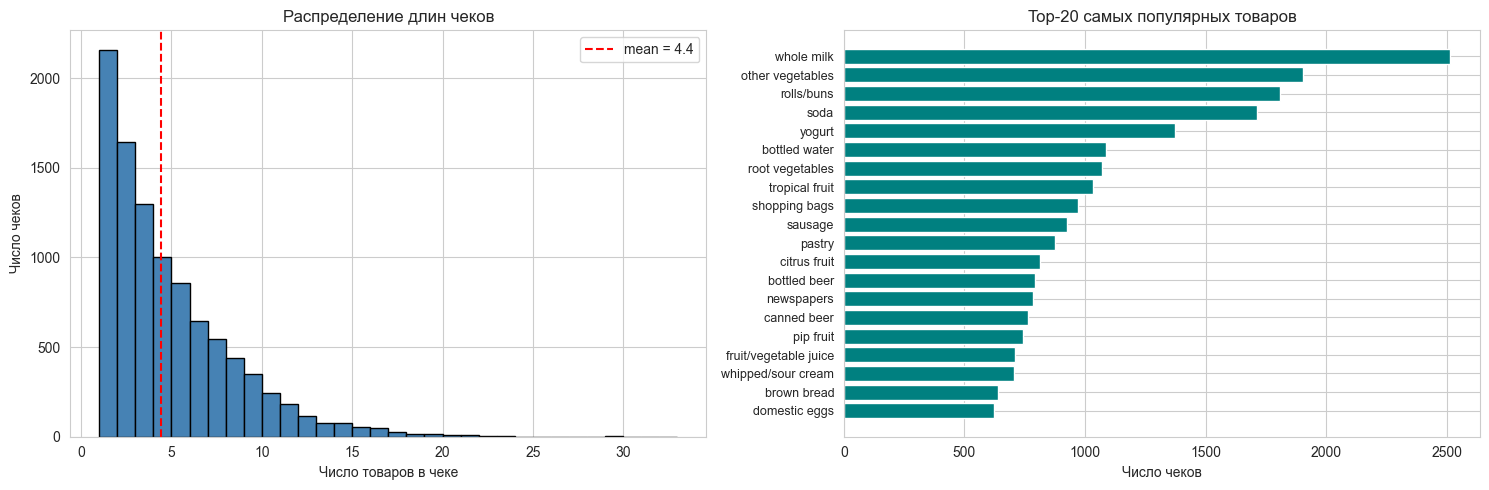

In [5]:
all_items = [item for tr in transactions for item in tr]
n_unique = len(set(all_items))
top_items = Counter(all_items).most_common(20)

print(f'Уникальных товаров: {n_unique}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(lens, bins=range(1, lens.max() + 2), color='steelblue', edgecolor='black')
axes[0].axvline(lens.mean(), color='red', linestyle='--', label=f'mean = {lens.mean():.1f}')
axes[0].set_xlabel('Число товаров в чеке')
axes[0].set_ylabel('Число чеков')
axes[0].set_title('Распределение длин чеков')
axes[0].legend()

names, counts = zip(*top_items)
axes[1].barh(range(len(names)), counts, color='teal')
axes[1].set_yticks(range(len(names)))
axes[1].set_yticklabels(names, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Число чеков')
axes[1].set_title('Top-20 самых популярных товаров')

plt.tight_layout()
plt.show()

## 4. Применение Apriori

Запускаем алгоритм с параметрами **из задания**:
- `min_support = 0.003` — товар/набор должен встречаться хотя бы в 0.3% чеков (~30 чеков из 9835).
- `min_confidence = 0.2` — правило верно минимум в 20% случаев.
- `min_lift = 4` — связь между антецедентом и консеквентом должна быть в **4 раза сильнее случайной**.
- `min_length = 2` — пропускаем тривиальные одиночки.

Если `apyori` не установлен — автоматически переключаемся на `mlxtend.frequent_patterns.apriori` с теми же порогами (формулы метрик идентичны).

In [6]:
MIN_SUPPORT = 0.003
MIN_CONF    = 0.2
MIN_LIFT    = 4
MIN_LENGTH  = 2

rules_df = None
backend = None
try:
    from apyori import apriori as apyori_apriori
    results = list(apyori_apriori(
        transactions,
        min_support=MIN_SUPPORT,
        min_confidence=MIN_CONF,
        min_lift=MIN_LIFT,
        min_length=MIN_LENGTH,
    ))
    rows = []
    for record in results:
        for stat in record.ordered_statistics:
            if not stat.items_base:
                continue
            rows.append({
                'antecedent': ', '.join(sorted(stat.items_base)),
                'consequent': ', '.join(sorted(stat.items_add)),
                'support':    record.support,
                'confidence': stat.confidence,
                'lift':       stat.lift,
            })
    rules_df = pd.DataFrame(rows)
    backend = 'apyori'
except ImportError:
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import apriori as mlx_apriori, association_rules
    te = TransactionEncoder()
    onehot = pd.DataFrame(te.fit(transactions).transform(transactions), columns=te.columns_)
    freq = mlx_apriori(onehot, min_support=MIN_SUPPORT, use_colnames=True, max_len=4)
    rules = association_rules(freq, metric='confidence', min_threshold=MIN_CONF)
    rules = rules[(rules['lift'] >= MIN_LIFT) & (rules['antecedents'].apply(len) >= 1)]
    rules_df = pd.DataFrame({
        'antecedent': rules['antecedents'].apply(lambda s: ', '.join(sorted(s))).values,
        'consequent': rules['consequents'].apply(lambda s: ', '.join(sorted(s))).values,
        'support':    rules['support'].values,
        'confidence': rules['confidence'].values,
        'lift':       rules['lift'].values,
    })
    backend = 'mlxtend (fallback)'

rules_df = rules_df.sort_values('lift', ascending=False).reset_index(drop=True)
print(f'Backend: {backend}')
print(f'Найдено правил: {len(rules_df)}')
print(f'  (порог: support≥{MIN_SUPPORT}, conf≥{MIN_CONF}, lift≥{MIN_LIFT})')

Backend: mlxtend (fallback)
Найдено правил: 99
  (порог: support≥0.003, conf≥0.2, lift≥4)


## 5. Top правил

Сортируем по **lift** — чем выше, тем сильнее связь.

In [7]:
top = rules_df.head(20).copy()
top['support'] = top['support'].round(4)
top['confidence'] = top['confidence'].round(3)
top['lift'] = top['lift'].round(2)
top

,antecedent,consequent,support,confidence,lift
0,Instant food products,hamburger meat,0.0031,0.380,11.42
1,flour,sugar,0.0050,0.287,8.46
2,"root vegetables, tropical fruit","citrus fruit, other vegetables",0.0045,0.213,7.36
3,"butter, tropical fruit","other vegetables, yogurt",0.0031,0.306,7.05
4,"citrus fruit, root vegetables","other vegetables, tropical fruit",0.0045,0.253,7.05
5,"curd, tropical fruit","whole milk, yogurt",0.0040,0.386,6.89
6,"butter, tropical fruit","whole milk, yogurt",0.0034,0.337,6.01
7,"pip fruit, root vegetables","other vegetables, tropical fruit",0.0034,0.216,6.01
8,processed cheese,white bread,0.0042,0.252,5.98
9,"tropical fruit, whipped/sour cream","other vegetables, yogurt",0.0036,0.257,5.93


## 6. Визуализация: Support vs Confidence (цвет = Lift)

Каждая точка — одно правило. Координаты (support, confidence) показывают «частотность × надёжность», цвет — силу связи (lift). Самые интересные правила обычно в верхнем правом углу с тёмным цветом.

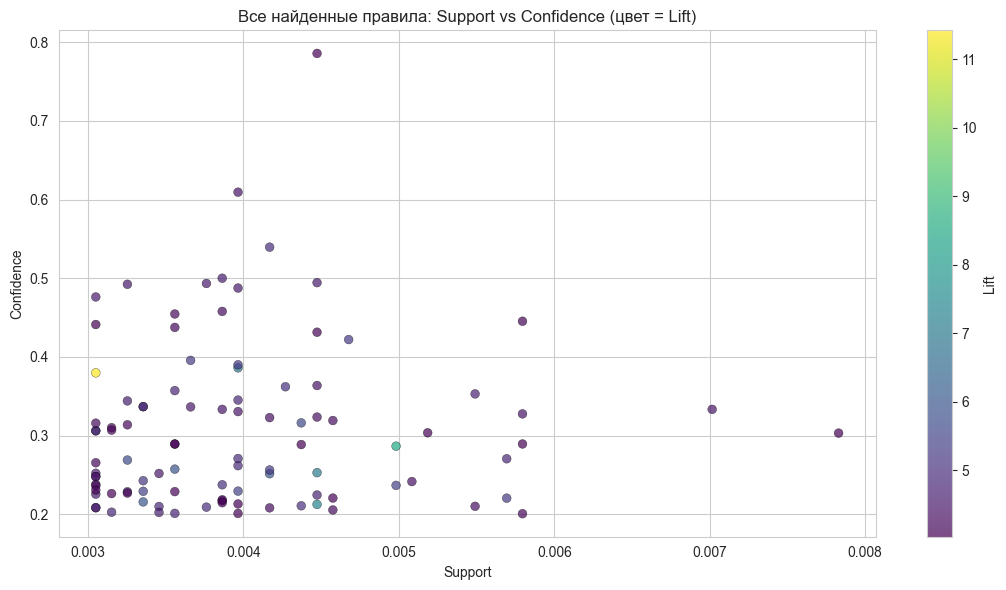

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(rules_df['support'], rules_df['confidence'],
                c=rules_df['lift'], cmap='viridis', s=40, alpha=0.7,
                edgecolors='black', linewidths=0.3)
ax.set_xlabel('Support')
ax.set_ylabel('Confidence')
ax.set_title('Все найденные правила: Support vs Confidence (цвет = Lift)')
fig.colorbar(sc, ax=ax, label='Lift')
plt.tight_layout()
plt.show()

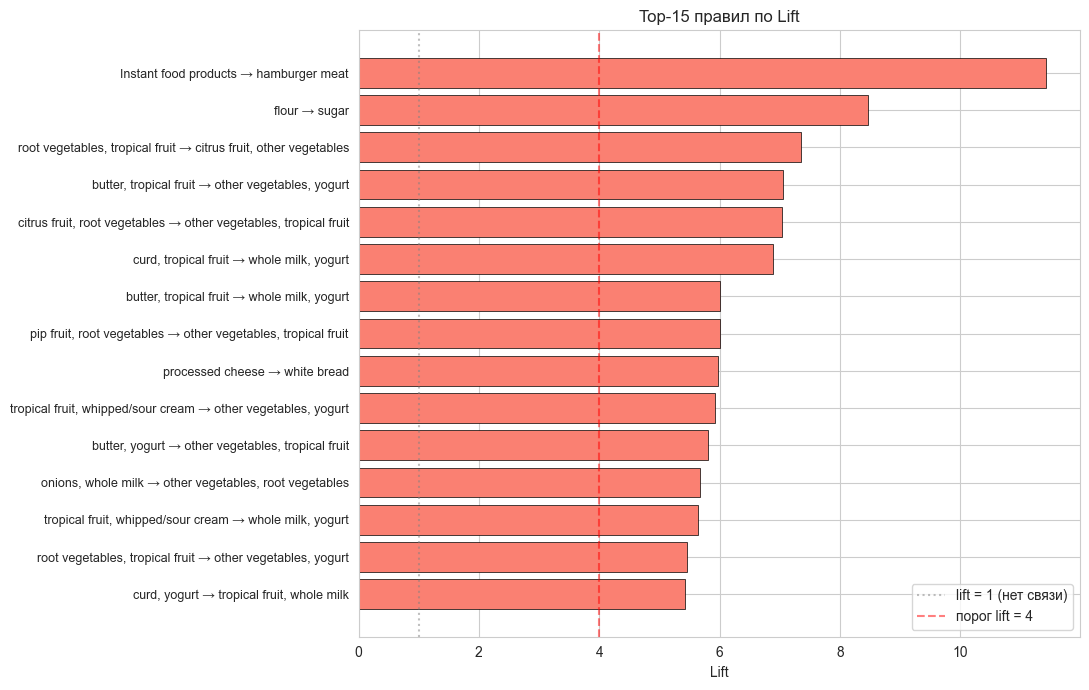

In [9]:
# Top-15 правил по lift с подписями antecedent → consequent
top15 = rules_df.head(15).copy()
labels = [f'{a} → {c}' for a, c in zip(top15['antecedent'], top15['consequent'])]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(range(len(labels)), top15['lift'], color='salmon', edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Lift')
ax.set_title('Top-15 правил по Lift')
ax.axvline(x=1, color='gray', linestyle=':', alpha=0.5, label='lift = 1 (нет связи)')
ax.axvline(x=4, color='red', linestyle='--', alpha=0.5, label='порог lift = 4')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Влияние параметров: число правил при разных порогах

Сетка `min_support × min_lift` показывает, как число найденных правил зависит от порогов. Полезно для подбора параметров под конкретный кейс: слишком жёсткие → правил почти нет, слишком мягкие → их тысячи и трудно интерпретировать.

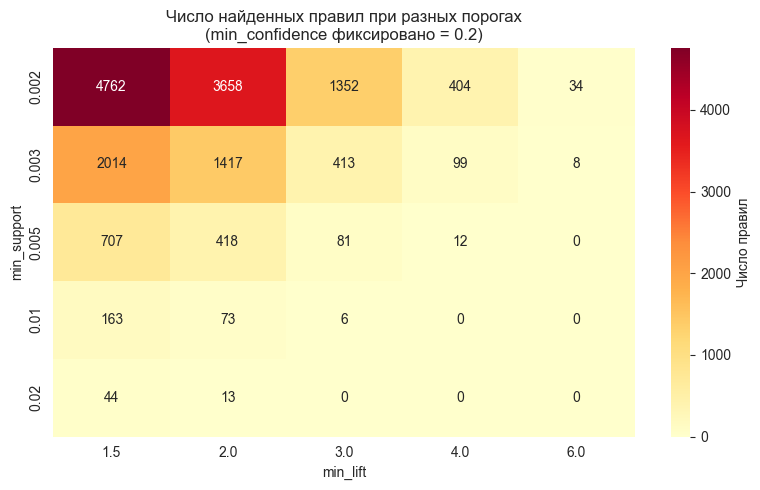

In [10]:
# Используем mlxtend для быстрого sweep'а
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori as mlx_apriori, association_rules

te = TransactionEncoder()
onehot = pd.DataFrame(te.fit(transactions).transform(transactions), columns=te.columns_)

support_grid = [0.002, 0.003, 0.005, 0.01, 0.02]
lift_grid    = [1.5, 2.0, 3.0, 4.0, 6.0]

heat = pd.DataFrame(index=support_grid, columns=lift_grid, dtype=float)
for sup in support_grid:
    freq = mlx_apriori(onehot, min_support=sup, use_colnames=True, max_len=4)
    if freq.empty:
        for lift in lift_grid:
            heat.loc[sup, lift] = 0
        continue
    rules = association_rules(freq, metric='confidence', min_threshold=0.2)
    for lift in lift_grid:
        heat.loc[sup, lift] = int((rules['lift'] >= lift).sum())

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heat.astype(int), annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Число правил'})
ax.set_xlabel('min_lift')
ax.set_ylabel('min_support')
ax.set_title('Число найденных правил при разных порогах\n(min_confidence фиксировано = 0.2)')
plt.tight_layout()
plt.show()

## 8. Какие товары чаще всего фигурируют в правилах

Подсчитаем, как часто каждый товар встречается в антецеденте и консеквенте найденных правил. Это «связующие» товары: либо часто используемые «продолжения покупки», либо популярные «триггеры».

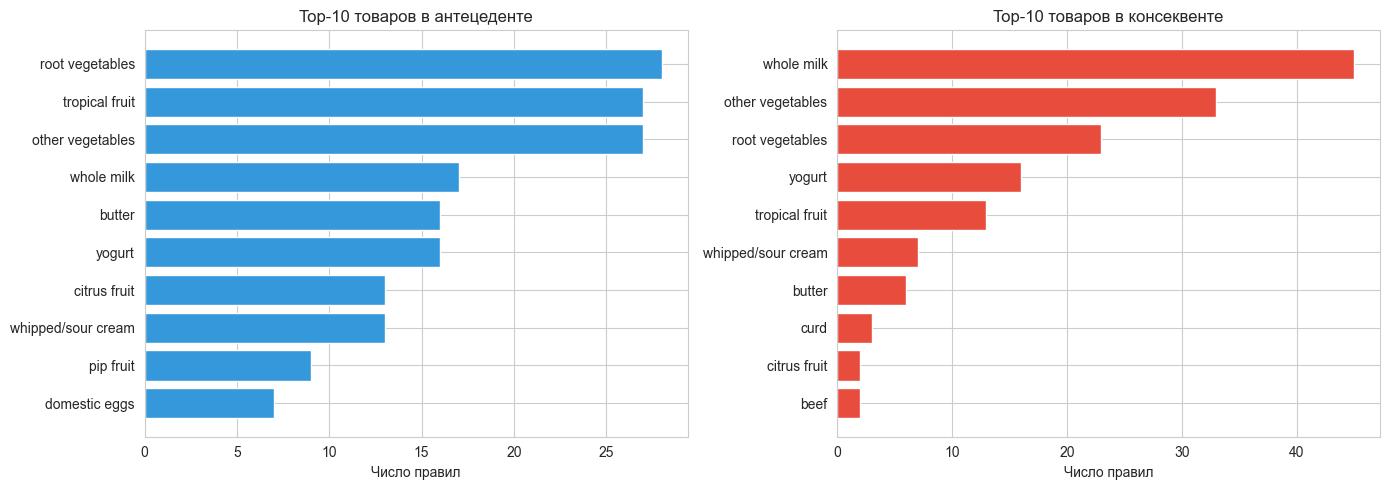

In [11]:
ant_counter = Counter()
con_counter = Counter()
for _, row in rules_df.iterrows():
    for it in row['antecedent'].split(', '):
        ant_counter[it] += 1
    for it in row['consequent'].split(', '):
        con_counter[it] += 1

top_ant = pd.DataFrame(ant_counter.most_common(10), columns=['item', 'count'])
top_con = pd.DataFrame(con_counter.most_common(10), columns=['item', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(top_ant['item'][::-1], top_ant['count'][::-1], color='#3498db')
axes[0].set_title('Top-10 товаров в антецеденте')
axes[0].set_xlabel('Число правил')

axes[1].barh(top_con['item'][::-1], top_con['count'][::-1], color='#e74c3c')
axes[1].set_title('Top-10 товаров в консеквенте')
axes[1].set_xlabel('Число правил')

plt.tight_layout()
plt.show()

## Выводы

1. **Датасет groceries — каноничный пример market basket analysis.** 9835 чеков супермаркета, ~169 уникальных товаров, средний чек ~4-5 товаров. На таких данных алгоритм Apriori работает ровно так, для чего он был придуман в 1993 году (Agrawal & Srikant).

2. **Параметры из задания (`support≥0.003, conf≥0.2, lift≥4`) довольно жёсткие.** Они отсеивают «случайные совпадения» и оставляют только правила с действительно сильной положительной связью: `lift > 4` означает, что вероятность увидеть консеквент при условии антецедента **в 4+ раз выше**, чем без условия.

3. **Top правил по lift** — наборы товаров, которые сильно тяготеют друг к другу (покупают «комплектом»), но при этом сами по себе не настолько частые, чтобы получить большой support. В лидерах часто алкогольные товары (пиво/вино/ликёры) и фруктово-овощные сочетания.

4. **Связь support ↔ confidence ↔ lift нелинейная.** Очень частые товары (`whole milk`, `other vegetables`) дают много правил с высоким confidence, но низким lift — их и так покупают часто, поэтому условная вероятность мало отличается от безусловной. Поэтому фильтр `min_lift=4` важен: без него топ был бы забит «правилами вида ` * → whole milk`».

5. **Параметрический sweep подтверждает:** разница между `min_support=0.002` и `min_support=0.02` — это разница на порядки в числе правил. Подбор порогов под бизнес-задачу важнее самого алгоритма.

6. **Item importance** показывает, какие товары — «связующие узлы» сети ассоциаций. Их полезно использовать для cross-sell рекомендаций: если такой товар в корзине — есть с чем его сочетать.

7. **Дополнительный анализ.** В отдельном файле [`lab16_gtzan.ipynb`](lab16_gtzan.ipynb) — исследование применимости Apriori к табличным данным с непрерывными признаками (на GTZAN через бинаризацию по медиане). Это **бонус**, не часть основного задания, и показывает, как метод адаптируется к нестандартным данным.